### 패키지 및 데이터

In [6]:
# ==================================================
# 기본 라이브러리
# ==================================================
import numpy as np
import seaborn as sb

from matplotlib import pyplot as plt
from pandas import DataFrame, concat


# ==================================================
# scikit-learn
# ==================================================
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


# ==================================================
# 불균형 데이터 처리 (imblearn)
# ==================================================
from imblearn.over_sampling import (
    RandomOverSampler,
    SMOTE,
)

from imblearn.under_sampling import RandomUnderSampler

# imblearn Pipeline (샘플링 + 모델 결합 시 사용)
from imblearn.pipeline import Pipeline as ImbPipeline


# ==================================================
# 사용자 정의 라이브러리
# ==================================================
from hossam import *


### 데이터

In [7]:
origin = load_data("pima_indians_diabetes_preprocessed")
origin.head()
origin.info()

캐글에서 제공하는 pima_indians_diabetes의 전처리 완료 버전(결측치 정제+로그변환) (출처: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    int64  
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


### 훈련, 검증 데이터 분리

In [8]:
df = origin.copy()

# 중요!!! 종속변수를 정수형으로 변환해야 한다.
df['Outcome'] = df['Outcome'].astype('int')
yname = "Outcome"
X = df.drop(columns=[yname])
y = df[yname]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=52)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

### 함수 정의

In [12]:
def hs_cls_bin_scores(estimator, X_test, y_test):
    # ===============================
    # 예측값 / 확률
    # ===============================
    y_pred_proba = estimator.predict_proba(X_test)[:, 1]
    y_pred = estimator.predict(X_test)

    # ===============================
    # McFadden pseudo R²
    # ===============================
    log_loss_test = -log_loss(y_test, y_pred_proba, normalize=False)

    y_null = np.ones_like(y_test) * (y_test.mean())
    log_loss_null = -log_loss(y_test, y_null, normalize=False)

    pseudo_r2 = 1 - (log_loss_test / log_loss_null)

    # ===============================
    # 혼동행렬
    # ===============================
    cm = confusion_matrix(y_test, y_pred)
    ((TN,FP), (FN, TP)) = cm

    # ===============================
    # 모델 클래스명
    # ===============================
    if hasattr(estimator, "named_steps"):
        class_name = estimator.named_steps["model"].__class__.__name__
    else:
        class_name = estimator.__class__.__name__

    # ===============================
    # AUC
    # ===============================
    auc_score = roc_auc_score(y_test, y_pred_proba)

    # ===============================
    # 성능 지표 DataFrame
    # ===============================
    score_df = DataFrame(
        {
            "의사결정계수(R2)": [pseudo_r2],
            "정확도(Accuracy)": [accuracy_score(y_test, y_pred)],
            "정밀도(Precision)": [precision_score(y_test, y_pred)],
            "재현율(Recall, TPR)": [recall_score(y_test, y_pred)],
            "위양성률(Fallout, FPR)": [FP / (TN + FP)],
            "특이성(TNR)": [TN / (TN + FP)],
            "F1 Score": [f1_score(y_test, y_pred)],
            "AUC": [auc_score],
        },
        index=[class_name],
    )

    # ===============================
    # ROC Curve
    # ===============================
    roc_fpr, roc_tpr, thresholds = roc_curve(y_test, y_pred_proba)

    my_dpi = 100
    width_px, height_px = 1000, 900
    rows, cols = 1, 1

    figsize = (width_px / my_dpi, height_px / my_dpi)
    fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

    sb.lineplot(x=roc_fpr, y=roc_tpr, ax=ax, label="ROC Curve")
    sb.lineplot(
        x=[0, 1],
        y=[0, 1],
        color="red",
        linestyle="--",
        alpha=0.5,
        ax=ax,
        label="Random",
    )

    ax.fill_between(roc_fpr, roc_tpr, alpha=0.1)

    ax.grid(True, alpha=0.3)
    ax.set_title(f"AUC = {auc_score:.4f}", fontsize=10, pad=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()

    plt.tight_layout()
    plt.show()
    plt.close()

    return score_df


### RaondomForest 분류 모형 적합

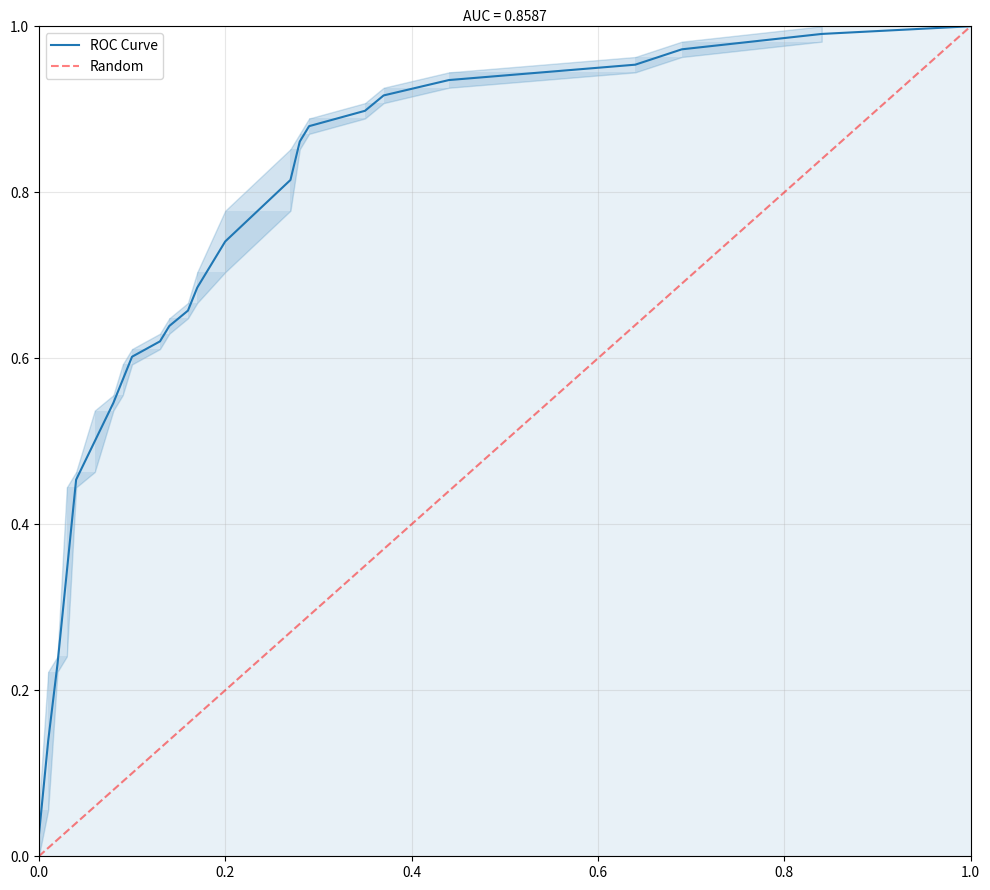

CPU times: total: 1.8 s
Wall time: 24.4 s


,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
RandomForestClassifier,0.278,0.747,0.609,0.778,0.270,0.730,0.683,0.859


In [13]:
%%time

# ==================================================
# 1. Pipeline 정의
# ==================================================
rf_cls_pipe = Pipeline(
    steps=[
        (
            "model",
            RandomForestClassifier(
                random_state=52,
                n_jobs=-1,
            ),
        ),
    ]
)


# ==================================================
# 2. 하이퍼파라미터 설정
# ==================================================
rf_cls_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [5, 10],
    "model__max_features": ["sqrt", 1.0],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced"],
}


# ==================================================
# 3. GridSearchCV
# ==================================================
rf_cls_gs = GridSearchCV(
    estimator=rf_cls_pipe,
    param_grid=rf_cls_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)


# ==================================================
# 4. 모델 학습
# ==================================================
rf_cls_gs.fit(X_train, y_train)

rf_cls_estimator = rf_cls_gs.best_estimator_


# ==================================================
# 5. 성능 평가
# ==================================================
rf_cls_score_df = hs_cls_bin_scores(
    rf_cls_estimator,
    X_test,
    y_test,
)

rf_cls_score_df


### 데이터 불균형의 이해

In [11]:
origin['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

### 데이터 불균형의 해결

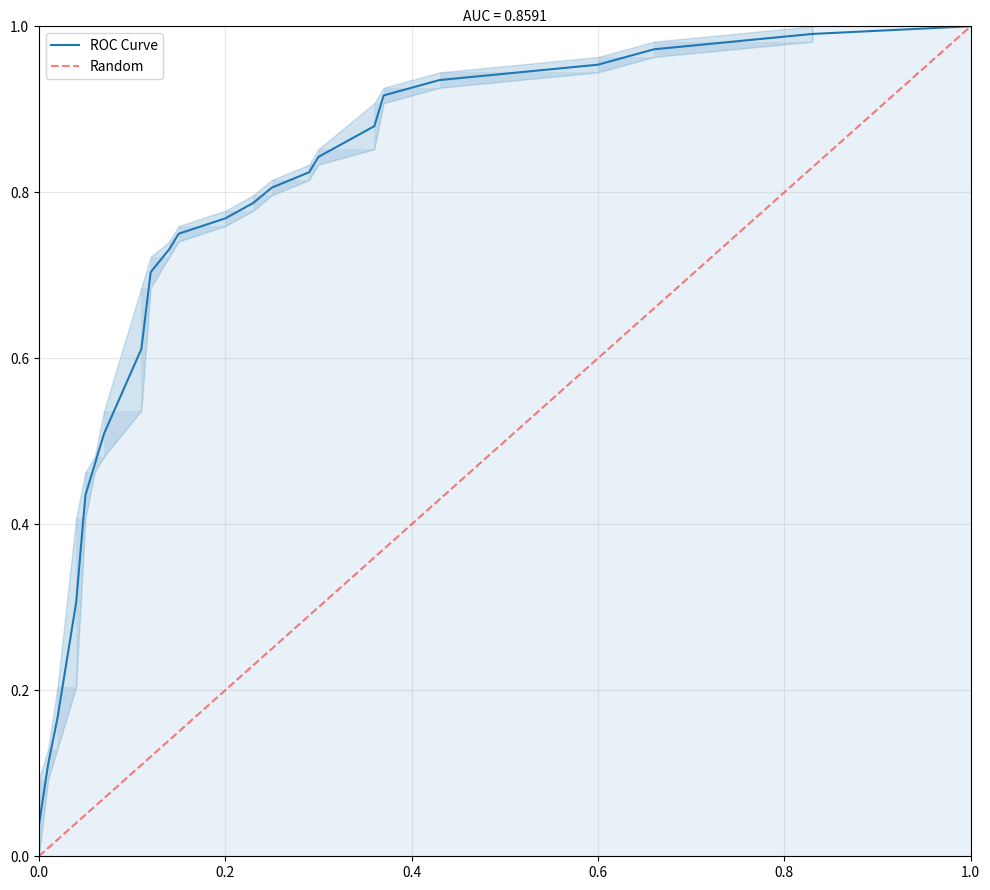

,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
기본,0.278,0.747,0.609,0.778,0.270,0.730,0.683,0.859
언더샘플링,0.241,0.760,0.620,0.815,0.270,0.730,0.704,0.859


In [14]:
# ==================================================
# 1. UnderSampling + RandomForest Pipeline
# ==================================================
rus_pipe = ImbPipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("rus", RandomUnderSampler(random_state=52)),
        (
            "model",
            RandomForestClassifier(
                random_state=52,
                n_jobs=-1,
            ),
        ),
    ]
)


# ==================================================
# 2. 하이퍼파라미터 설정
# ==================================================
rus_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [5, 10],
    "model__max_features": ["sqrt", 1.0],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced"],
}


# ==================================================
# 3. GridSearchCV
# ==================================================
rus_gs = GridSearchCV(
    estimator=rus_pipe,
    param_grid=rus_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)


# ==================================================
# 4. 모델 학습
# ==================================================
rus_gs.fit(X_train, y_train)

rus_estimator = rus_gs.best_estimator_


# ==================================================
# 5. 성능 평가
# ==================================================
rus_score_df = hs_cls_bin_scores(
    rus_estimator,
    X_test,
    y_test,
)


# ==================================================
# 6. 기존 RF vs UnderSampling 비교
# ==================================================
rdf = concat(
    [rf_cls_score_df, rus_score_df],
    axis=0,
)

rdf.index = ["기본", "언더샘플링"]

rdf


### Random Over Sampling 

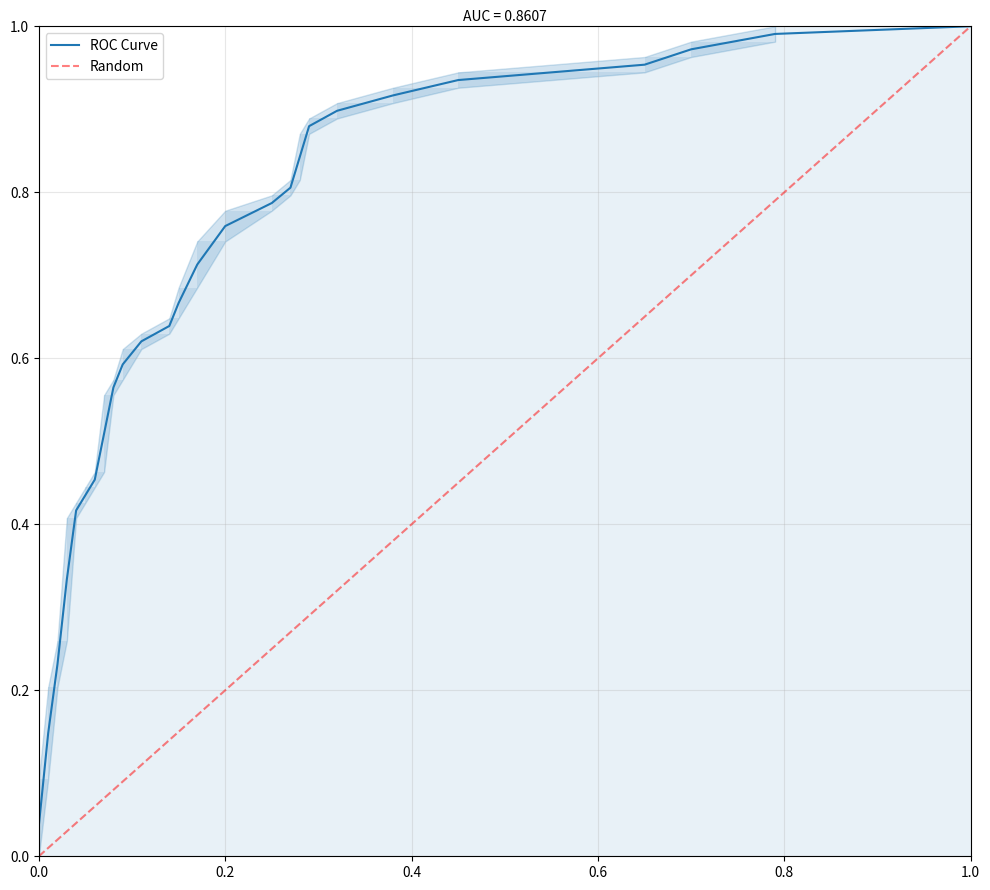

,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
기본,0.278,0.747,0.609,0.778,0.270,0.730,0.683,0.859
언더샘플링,0.241,0.760,0.620,0.815,0.270,0.730,0.704,0.859
오버샘플링,0.273,0.760,0.620,0.815,0.270,0.730,0.704,0.861


In [15]:
# ==================================================
# 1. OverSampling + RandomForest Pipeline
# ==================================================
ros_pipe = ImbPipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("ros", RandomOverSampler(random_state=52)),
        (
            "model",
            RandomForestClassifier(
                random_state=52,
                n_jobs=-1,
            ),
        ),
    ]
)


# ==================================================
# 2. 하이퍼파라미터 설정
# ==================================================
ros_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [5, 10],
    "model__max_features": ["sqrt", 1.0],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced"],
}


# ==================================================
# 3. GridSearchCV
# ==================================================
ros_gs = GridSearchCV(
    estimator=ros_pipe,
    param_grid=ros_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)


# ==================================================
# 4. 모델 학습
# ==================================================
ros_gs.fit(X_train, y_train)

ros_estimator = ros_gs.best_estimator_


# ==================================================
# 5. 성능 평가
# ==================================================
ros_score_df = hs_cls_bin_scores(
    ros_estimator,
    X_test,
    y_test,
)


# ==================================================
# 6. 기본 / 언더 / 오버 비교
# ==================================================
rdf = concat(
    [
        rf_cls_score_df,
        rus_score_df,
        ros_score_df,
    ],
    axis=0,
)

rdf.index = ["기본", "언더샘플링", "오버샘플링"]

rdf


### SMOTE

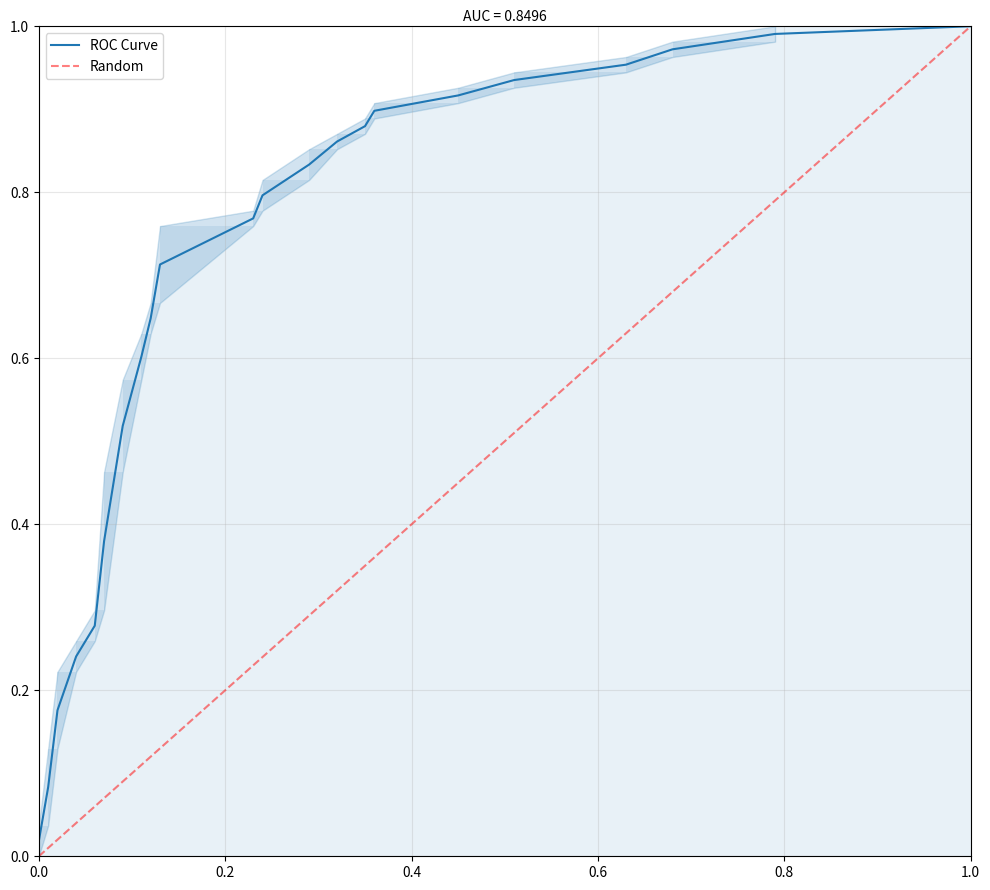

,의사결정계수(R2),정확도(Accuracy),정밀도(Precision),"재현율(Recall, TPR)","위양성률(Fallout, FPR)",특이성(TNR),F1 Score,AUC
기본,0.278,0.747,0.609,0.778,0.270,0.730,0.683,0.859
언더샘플링,0.241,0.760,0.620,0.815,0.270,0.730,0.704,0.859
오버샘플링,0.273,0.760,0.620,0.815,0.270,0.730,0.704,0.861
SMOTE,0.251,0.766,0.629,0.815,0.260,0.740,0.710,0.850


In [16]:
# ==================================================
# 1. SMOTE + RandomForest Pipeline
# ==================================================
sm_pipe = ImbPipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("sm", SMOTE(random_state=52, k_neighbors=5)),
        (
            "model",
            RandomForestClassifier(
                random_state=52,
                n_jobs=-1,
            ),
        ),
    ]
)


# ==================================================
# 2. 하이퍼파라미터 설정
# ==================================================
sm_param_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 10],
    "model__min_samples_leaf": [5, 10],
    "model__max_features": ["sqrt", 1.0],
    "model__criterion": ["gini", "entropy"],
    "model__class_weight": [None, "balanced"],
}


# ==================================================
# 3. GridSearchCV
# ==================================================
sm_gs = GridSearchCV(
    estimator=sm_pipe,
    param_grid=sm_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)


# ==================================================
# 4. 모델 학습
# ==================================================
sm_gs.fit(X_train, y_train)

sm_estimator = sm_gs.best_estimator_


# ==================================================
# 5. 성능 평가
# ==================================================
sm_score_df = hs_cls_bin_scores(
    sm_estimator,
    X_test,
    y_test,
)


# ==================================================
# 6. 전체 비교 (기본 / 언더 / 오버 / SMOTE)
# ==================================================
rdf = concat(
    [
        rf_cls_score_df,
        rus_score_df,
        ros_score_df,
        sm_score_df,
    ],
    axis=0,
)

rdf.index = ["기본", "언더샘플링", "오버샘플링", "SMOTE"]

rdf
